In [2]:
# Zelle 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
import pymongo
import os
from tensorflow.keras.utils import Sequence, to_categorical
import gc  # Garbage Collector


In [3]:
# Zelle 2: Datenbankverbindung und Datenladung
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    # Daten laden
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    # In DataFrames konvertieren
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    # Merge der DataFrames
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                        left_on='fingerprintId', 
                        right_on='_id', 
                        suffixes=('_sample', '_fingerprint'))
    
    return merged_df

# Daten laden
merged_df = load_data()
print(f"Gesamtdatensatz enthält {len(merged_df)} Einträge.")

Gesamtdatensatz enthält 2000000 Einträge.


In [4]:
# Benutzer-IDs extrahieren
user_ids = merged_df['username'].unique()

# DataFrames für jeden Benutzer erstellen
user_dfs = {user_id: merged_df[merged_df['username'] == user_id] for user_id in user_ids}

# Beispielhafte Anzeige der ersten 5 Zeilen für jeden Benutzer
for user_id, df in user_dfs.items():
    print(f"Erste 5 Zeilen für Benutzer {user_id}:")
    display(df.head())

Erste 5 Zeilen für Benutzer benutzername_1:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
0,66e326e9fab6918841db55df,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.906,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
1,66e326e9fab6918841db55db,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.847,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
2,66e326e9fab6918841db55d6,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.772,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
3,66e326e9fab6918841db55e3,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.981,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
4,66e326eafab6918841db55eb,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:46.118,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0


Erste 5 Zeilen für Benutzer benutzername_3:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
100000,6703f8369717b7a0d179d6e3,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.318,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100001,6703f8369717b7a0d179d6e7,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.339,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100002,6703f8369717b7a0d179d6eb,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.359,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100003,6703f8369717b7a0d179d6ef,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.379,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100004,6703f8369717b7a0d179d6f7,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.412,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0


Erste 5 Zeilen für Benutzer benutzername_4:


...

,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
1700000,6707bdebffc8085dd61d7c85,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.742,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700001,6707bdebffc8085dd61d7c8d,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.756,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700002,6707bdebffc8085dd61d7c99,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.773,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700003,6707bdebffc8085dd61d7ca1,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.787,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700004,6707bdebffc8085dd61d7ca9,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.803,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0


Erste 5 Zeilen für Benutzer benutzername_21:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
1800000,6707c487ffc8085dd625a040,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.494,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800001,6707c487ffc8085dd625a044,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.506,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800002,6707c487ffc8085dd625a048,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.517,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800003,6707c487ffc8085dd625a04c,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.528,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800004,6707c487ffc8085dd625a050,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.539,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0


Erste 5 Zeilen für Benutzer benutzername_22:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
1900000,6707cabdffc8085dd62a72c5,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.957,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900001,6707cabdffc8085dd62a72d1,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.970,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900002,6707cabdffc8085dd62a72ca,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.964,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900003,6707cabdffc8085dd62a72dd,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.981,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900004,6707cabdffc8085dd62a72e1,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.985,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import gc  # Garbage Collector
from tqdm import tqdm  # Fortschrittsbalken
# Funktion zur Verarbeitung der Bilder in RGB
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Konvertiere Bild zu RGB
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0  # Normalisierung auf Werte zwischen 0 und 1
        return image_array
    except Exception as e:
        print(f"Fehler bei der Bildverarbeitung: {e}")
        return None

def extract_images_from_df(df):
    images = []
    labels = []
    for _, row in tqdm(df.iterrows(), total=df.shape[0], desc="Lade Bilder"):
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels)



In [6]:
# Beispiel für Benutzer 1
example_user_id = 'benutzername_1'
user_df = user_dfs[example_user_id].sample(n=15000, random_state=42)  # Zufällige Stichprobe von 40.000 positiven Beispielen

# Negative Beispiele hinzufügen und begrenzen
negative_df = pd.concat([user_dfs[user_id] for user_id in user_ids if user_id != example_user_id])
negative_df = negative_df.sample(n=10000, random_state=42)  # Zufällige Stichprobe von 10.000 negativen Beispielen

# Aufteilung in Train/Val/Test-Sets (70% Train, 20% Val, 10% Test)
train_df, test_df = train_test_split(pd.concat([user_df, negative_df]), test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2222, random_state=42)  # 0.2222 * 0.9 ≈ 0.2

# Bilddaten verarbeiten
try:
    X_train, y_train = extract_images_from_df(train_df)
    X_val, y_val = extract_images_from_df(val_df)
    X_test, y_test = extract_images_from_df(test_df)

    # One-Hot-Encoding der Labels entfernen
    # y_train = to_categorical(y_train, num_classes=2)
    # y_val = to_categorical(y_val, num_classes=2)
    # y_test = to_categorical(y_test, num_classes=2)
except Exception as e:
    print(f"Fehler bei der Bilddatenverarbeitung: {e}")

# Speicher freigeben
gc.collect()

Lade Bilder: 100%|██████████| 2500/2500 [00:01<00:00, 1412.20it/s]


0

In [7]:

# Einfaches CNN-Modell definieren
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Modell kompilieren
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Modellübersicht anzeigen
model.summary()

2024-11-23 14:41:49.360683: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-23 14:41:49.360795: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-23 14:41:49.418423: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 128)       0

ion/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-23 14:41:49.509980: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-23 14:41:49.510042: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-23 14:41:49.510100: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/

In [ ]:
# Modell trainieren
try:
    history = model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val))
except Exception as e:
    print(f"Fehler beim Training des Modells: {e}")


Epoch 1/50


2024-11-23 14:41:59.555317: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8906
2024-11-23 14:41:59.813997: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2024-11-23 14:41:59.852863: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7e3caa65fc60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-11-23 14:41:59.852883: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2024-11-23 14:41:59.852886: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA RTX A6000, Compute Capability 8.6
2024-11-23 14:41:59.859812: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-11-23 14:41:59.94845

547/547 [==============================] - 13s 22ms/step - loss: 0.3585 - accuracy: 0.8548 - val_loss: 0.2345 - val_accuracy: 0.9292
Epoch 2/50
547/547 [==============================] - 9s 16ms/step - loss: 0.2163 - accuracy: 0.9383 - val_loss: 0.2217 - val_accuracy: 0.9320
Epoch 3/50
547/547 [==============================] - 9s 16ms/step - loss: 0.2163 - accuracy: 0.9367 - val_loss: 0.2233 - val_accuracy: 0.9312
Epoch 4/50
547/547 [==============================] - 9s 16ms/step - loss: 0.2186 - accuracy: 0.9346 - val_loss: 0.2244 - val_accuracy: 0.9318
Epoch 5/50
547/547 [==============================] - 9s 17ms/step - loss: 0.2063 - accuracy: 0.9401 - val_loss: 0.2481 - val_accuracy: 0.9242
Epoch 6/50
547/547 [==============================] - 9s 17ms/step - loss: 0.2133 - accuracy: 0.9368 - val_loss: 0.2229 - val_accuracy: 0.9318
Epoch 7/50
547/547 [==============================] - 9s 16ms/step - loss: 0.2028 - accuracy: 0.9404 - val_loss: 0.2293 - val_accuracy: 0.9320
Epoch 8/5

In [ ]:
# Modell evaluieren
try:
    loss, accuracy = model.evaluate(X_test, y_test)
    print(f"Test Loss: {loss}")
    print(f"Test Accuracy: {accuracy}")
except Exception as e:
    print(f"Fehler bei der Modellbewertung: {e}")

# Vorhersagen auf Testdaten
try:
    y_pred = model.predict(X_test)
    y_pred_classes = (y_pred > 0.5).astype("int32").flatten()
    y_true = y_test  # Keine Anpassung der Form notwendig

    # Klassifikationsbericht
    print(classification_report(y_true, y_pred_classes))

    # Konfusionsmatrix
    conf_matrix = confusion_matrix(y_true, y_pred_classes)
    sns.heatmap(conf_matrix, annot=True, fmt='d')
    plt.title('Konfusionsmatrix')
    plt.xlabel('Vorhergesagte Klasse')
    plt.ylabel('Wahre Klasse')
    plt.show()

    # ROC-Kurve
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.show()
except Exception as e:
    print(f"Fehler bei der Vorhersage und Auswertung: {e}")

Fehler bei der Modellbewertung: name 'model' is not defined
Fehler bei der Vorhersage und Auswertung: name 'model' is not defined


In [ ]:
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Funktion zur Auswahl zufälliger Samples von verschiedenen Benutzern
def get_random_samples(user_dfs, example_user_id, num_users=5, num_samples_per_user=10):
    selected_users = random.sample([user_id for user_id in user_dfs.keys() if user_id != example_user_id], num_users)
    samples = []
    labels = []
    user_labels = []
    
    for user_id in selected_users:
        user_samples = user_dfs[user_id].sample(n=num_samples_per_user, random_state=42)
        for _, row in user_samples.iterrows():
            image = process_image_rgb(row['sampleData'])
            if image is not None:
                samples.append(image)
                labels.append(0)  # Negative Beispiel
                user_labels.append(user_id)
    
    # Füge positive Beispiele hinzu
    user_samples = user_dfs[example_user_id].sample(n=num_samples_per_user, random_state=42)
    for _, row in user_samples.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            samples.append(image)
            labels.append(1)  # Positive Beispiel
            user_labels.append(example_user_id)
    
    return np.array(samples), np.array(labels), user_labels

# Funktion zur Durchführung der Analyse
def analyze_model(model, user_dfs, example_user_id, iterations=5, num_users=5, num_samples_per_user=10):
    all_results = []
    
    for i in range(iterations):
        X_samples, y_samples, user_labels = get_random_samples(user_dfs, example_user_id, num_users, num_samples_per_user)
        y_pred = model.predict(X_samples)
        y_pred_classes = (y_pred > 0.5).astype("int32").flatten()
        
        # Textuelle Analyse
        print(f"Iteration {i+1}")
        print(classification_report(y_samples, y_pred_classes))
        
        # Konfusionsmatrix
        conf_matrix = confusion_matrix(y_samples, y_pred_classes)
        sns.heatmap(conf_matrix, annot=True, fmt='d')
        plt.title(f'Konfusionsmatrix - Iteration {i+1}')
        plt.xlabel('Vorhergesagte Klasse')
        plt.ylabel('Wahre Klasse')
        plt.show()
        
        # ROC-Kurve
        fpr, tpr, _ = roc_curve(y_samples, y_pred)
        roc_auc = auc(fpr, tpr)
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic (ROC) - Iteration {i+1}')
        plt.legend(loc="lower right")
        plt.show()
        
        all_results.append((y_samples, y_pred_classes, user_labels))
    
    return all_results

# Funktion zur grafischen Darstellung der Benutzerklassifikationen
def plot_user_classifications(results, example_user_id):
    for i, (y_samples, y_pred_classes, user_labels) in enumerate(results):
        df = pd.DataFrame({'User': user_labels, 'True Label': y_samples, 'Predicted Label': y_pred_classes})
        df['Correct'] = df['True Label'] == df['Predicted Label']
        
        plt.figure(figsize=(12, 6))
        sns.countplot(data=df, x='User', hue='Correct', palette={True: 'green', False: 'red'})
        plt.title(f'User Classification Results - Iteration {i+1}')
        plt.xlabel('User')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.legend(title='Correct Prediction')
        plt.show()

# Beispiel für Benutzer 1
example_user_id = 'benutzername_1'

# Analyse durchführen
results = analyze_model(model, user_dfs, example_user_id)

# Grafische Darstellung der Benutzerklassifikationen
plot_user_classifications(results, example_user_id)

NameError: name 'model' is not defined

2/2 [==============================] - 0s 5ms/step
Iteration 1
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60

2/2 [==============================] - 0s 5ms/step
Iteration 2
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificat

2/2 [==============================] - 0s 5ms/step
Iteration 3
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60

2/2 [==============================] - 0s 5ms/step
Iteration 4
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificat

2/2 [==============================] - 0s 5ms/step
Iteration 5
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60

2/2 [==============================] - 0s 6ms/step
Iteration 6
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificat

2/2 [==============================] - 0s 5ms/step
Iteration 7
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60

2/2 [==============================] - 0s 5ms/step
Iteration 8
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificat

2/2 [==============================] - 0s 6ms/step
Iteration 9
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60

2/2 [==============================] - 0s 5ms/step
Iteration 10
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificat

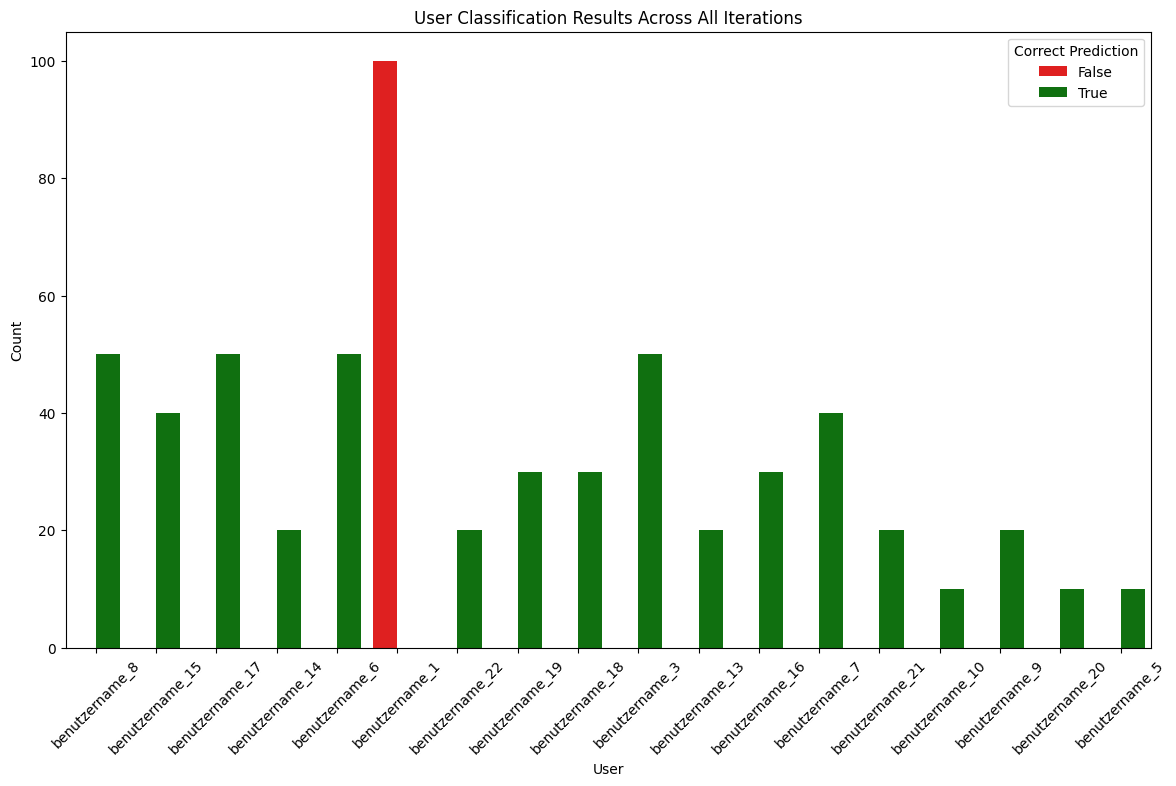

In [ ]:
# Funktion zur grafischen Darstellung der Benutzerklassifikationen für alle Iterationen
def plot_user_classifications_all_iterations(results, example_user_id):
    combined_df = pd.DataFrame()
    
    for i, (y_samples, y_pred_classes, user_labels) in enumerate(results):
        df = pd.DataFrame({'User': user_labels, 'True Label': y_samples, 'Predicted Label': y_pred_classes})
        df['Correct'] = df['True Label'] == df['Predicted Label']
        df['Iteration'] = i + 1
        combined_df = pd.concat([combined_df, df], ignore_index=True)
    
    plt.figure(figsize=(14, 8))
    sns.countplot(data=combined_df, x='User', hue='Correct', palette={True: 'green', False: 'red'}, dodge=True)
    plt.title('User Classification Results Across All Iterations')
    plt.xlabel('User')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Correct Prediction')
    plt.show()

# Beispiel für Benutzer 1
example_user_id = 'benutzername_1'

# Analyse durchführen
results = analyze_model(model, user_dfs, example_user_id)

# Grafische Darstellung der Benutzerklassifikationen für alle Iterationen
plot_user_classifications_all_iterations(results, example_user_id)

2/2 [==============================] - 0s 6ms/step
Iteration 1
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60

2/2 [==============================] - 0s 6ms/step
Iteration 2
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificat

2/2 [==============================] - 0s 6ms/step
Iteration 3
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60

2/2 [==============================] - 0s 6ms/step
Iteration 4
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificat

2/2 [==============================] - 0s 5ms/step
Iteration 5
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60

2/2 [==============================] - 0s 5ms/step
Iteration 6
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificat

2/2 [==============================] - 0s 6ms/step
Iteration 7
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60

2/2 [==============================] - 0s 5ms/step
Iteration 8
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificat

2/2 [==============================] - 0s 6ms/step
Iteration 9
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60

2/2 [==============================] - 0s 6ms/step
Iteration 10
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificat

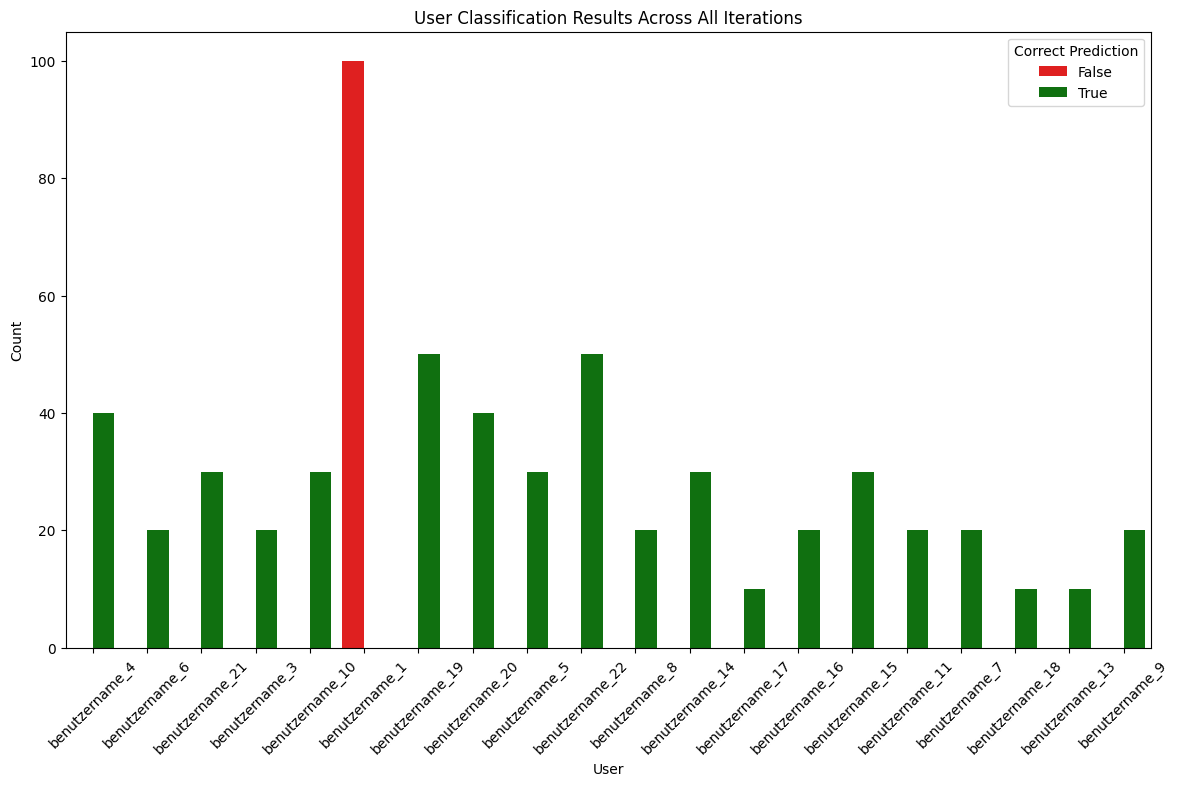

In [ ]:
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import pandas as pd

# Funktion zur Auswahl zufälliger Samples von verschiedenen Benutzern
def get_random_samples(user_dfs, example_user_id, num_users=5, num_samples_per_user=10):
    selected_users = random.sample([user_id for user_id in user_dfs.keys() if user_id != example_user_id], num_users)
    samples = []
    labels = []
    user_labels = []
    
    for user_id in selected_users:
        user_samples = user_dfs[user_id].sample(n=num_samples_per_user, random_state=42)
        for _, row in user_samples.iterrows():
            image = process_image_rgb(row['sampleData'])
            if image is not None:
                samples.append(image)
                labels.append(0)  # Negative Beispiel
                user_labels.append(user_id)
    
    # Füge positive Beispiele hinzu
    user_samples = user_dfs[example_user_id].sample(n=num_samples_per_user, random_state=42)
    for _, row in user_samples.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            samples.append(image)
            labels.append(1)  # Positive Beispiel
            user_labels.append(example_user_id)
    
    return np.array(samples), np.array(labels), user_labels

# Funktion zur Durchführung der Analyse
def analyze_model(model, user_dfs, example_user_id, iterations=10, num_users=5, num_samples_per_user=10):
    all_results = []
    
    for i in range(iterations):
        X_samples, y_samples, user_labels = get_random_samples(user_dfs, example_user_id, num_users, num_samples_per_user)
        y_pred = model.predict(X_samples)
        y_pred_classes = (y_pred > 0.5).astype("int32").flatten()
        
        # Textuelle Analyse
        print(f"Iteration {i+1}")
        print(classification_report(y_samples, y_pred_classes))
        
        all_results.append((y_samples, y_pred_classes, user_labels))
    
    return all_results

# Funktion zur grafischen Darstellung der Benutzerklassifikationen für alle Iterationen
def plot_user_classifications_all_iterations(results, example_user_id):
    combined_df = pd.DataFrame()
    
    for i, (y_samples, y_pred_classes, user_labels) in enumerate(results):
        df = pd.DataFrame({'User': user_labels, 'True Label': y_samples, 'Predicted Label': y_pred_classes})
        df['Correct'] = df['True Label'] == df['Predicted Label']
        df['Iteration'] = i + 1
        combined_df = pd.concat([combined_df, df], ignore_index=True)
    
    plt.figure(figsize=(14, 8))
    sns.countplot(data=combined_df, x='User', hue='Correct', palette={True: 'green', False: 'red'}, dodge=True)
    plt.title('User Classification Results Across All Iterations')
    plt.xlabel('User')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Correct Prediction')
    plt.show()

# Beispiel für Benutzer 1
example_user_id = 'benutzername_1'

# Analyse durchführen
results = analyze_model(model, user_dfs, example_user_id, iterations=10)

# Grafische Darstellung der Benutzerklassifikationen für alle Iterationen
plot_user_classifications_all_iterations(results, example_user_id)

1/2 [==============>...............] - ETA: 0s

2024-11-13 15:40:13.086732: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8906
2024-11-13 15:40:13.171356: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 532.00MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2024-11-13 15:40:13.235249: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2024-11-13 15:40:13.272232: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 467.50MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


2/2 [==============================] - 0s 75ms/step
Iteration 1
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60

2/2 [==============================] - 0s 6ms/step
Iteration 2
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificat

2/2 [==============================] - 0s 6ms/step
Iteration 3
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60

2/2 [==============================] - 0s 6ms/step
Iteration 4
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60



...

/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificat

2/2 [==============================] - 0s 6ms/step
Iteration 13
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60

2/2 [==============================] - 0s 6ms/step
Iteration 14
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificat

2/2 [==============================] - 0s 6ms/step
Iteration 15
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        50
           1       0.00      0.00      0.00        10

    accuracy                           0.83        60
   macro avg       0.42      0.50      0.45        60
weighted avg       0.69      0.83      0.76        60



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


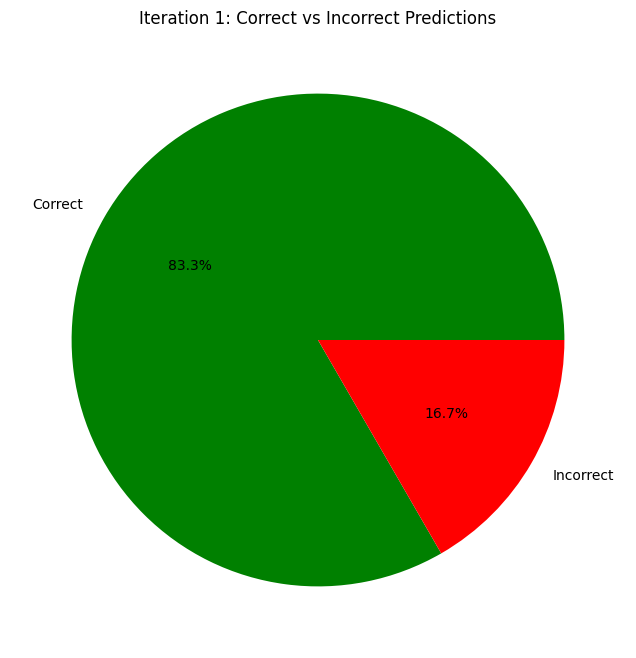

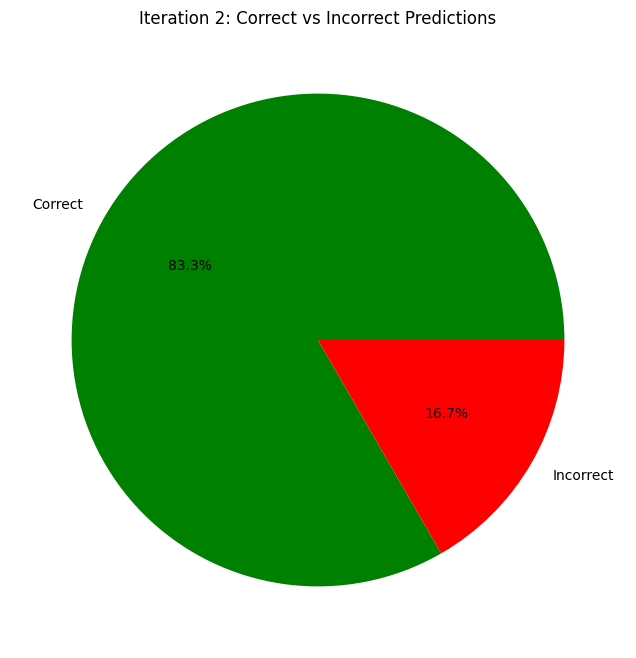

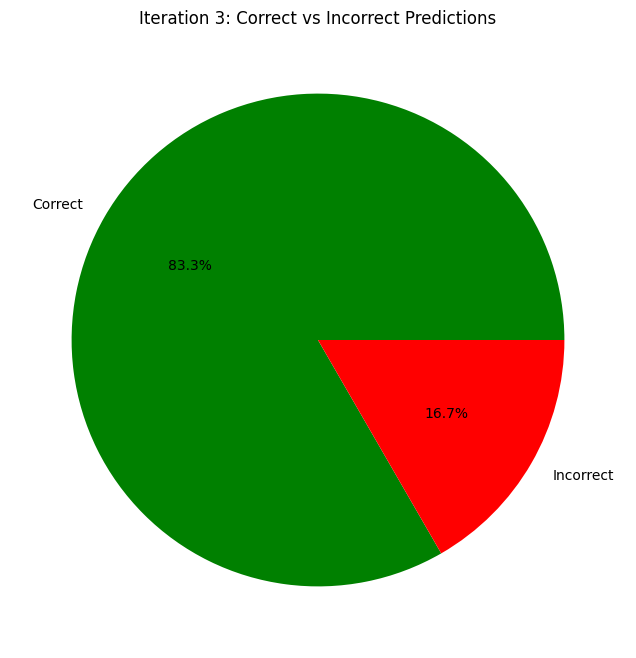

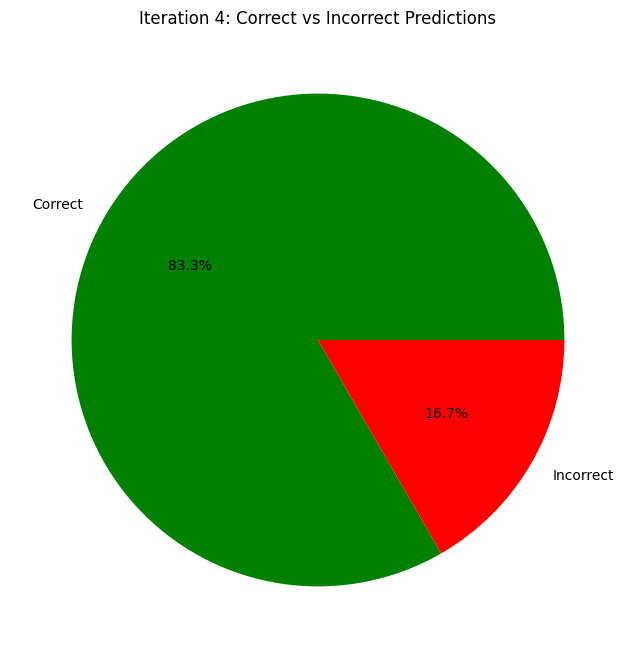

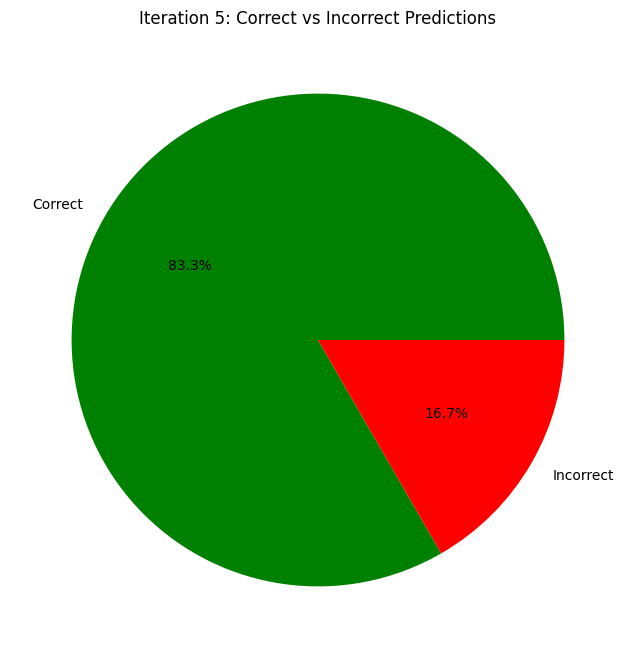

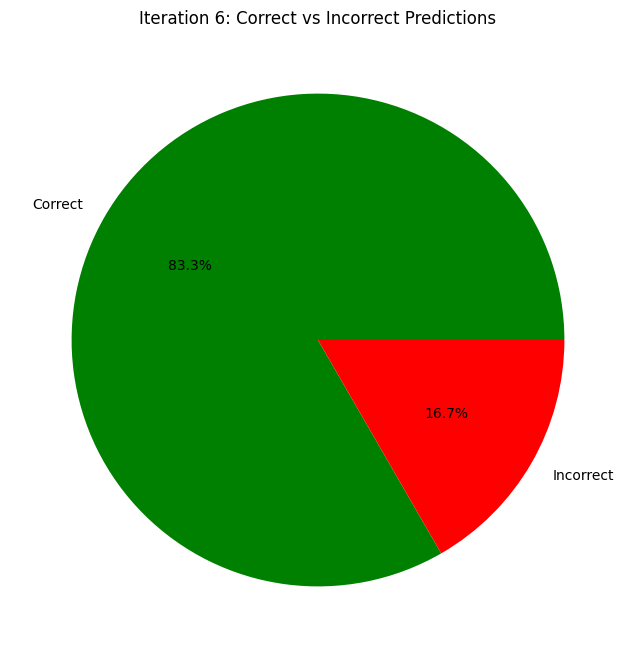

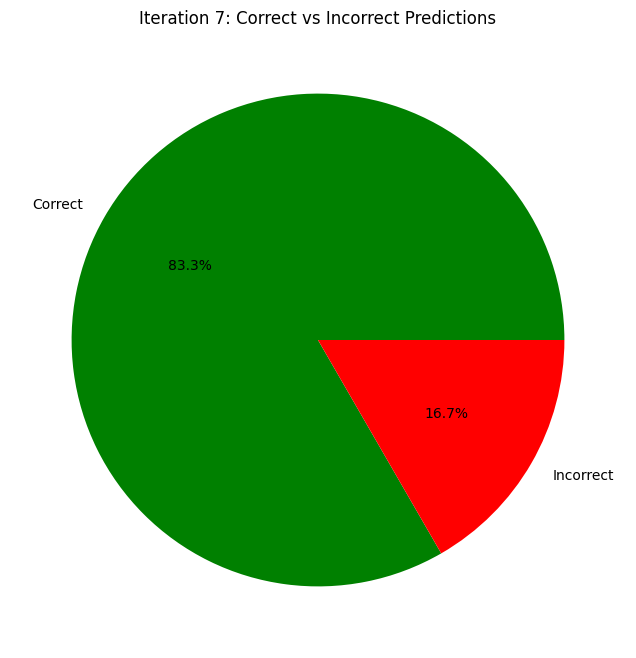

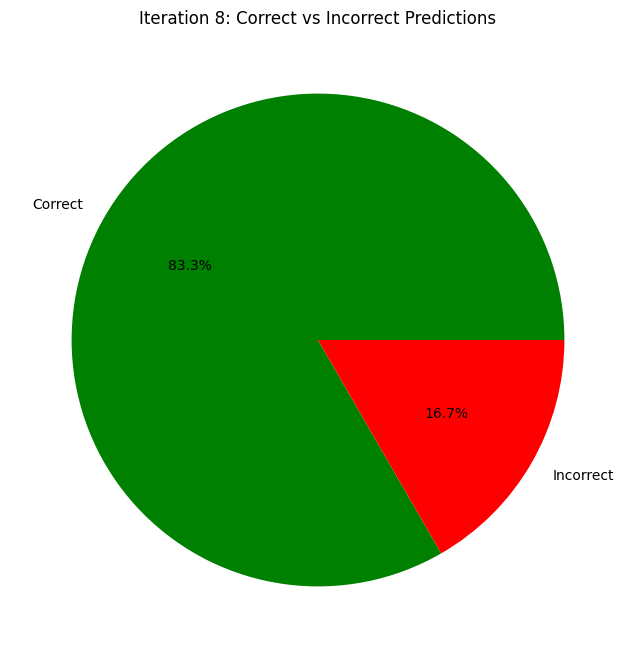

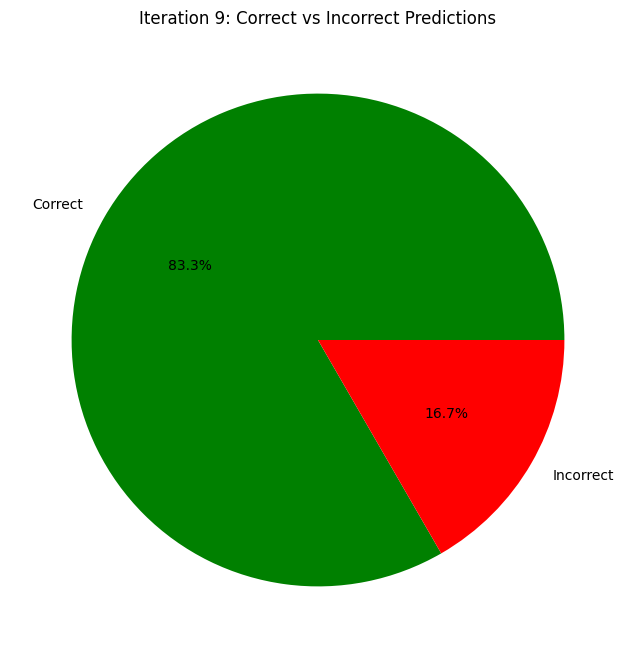

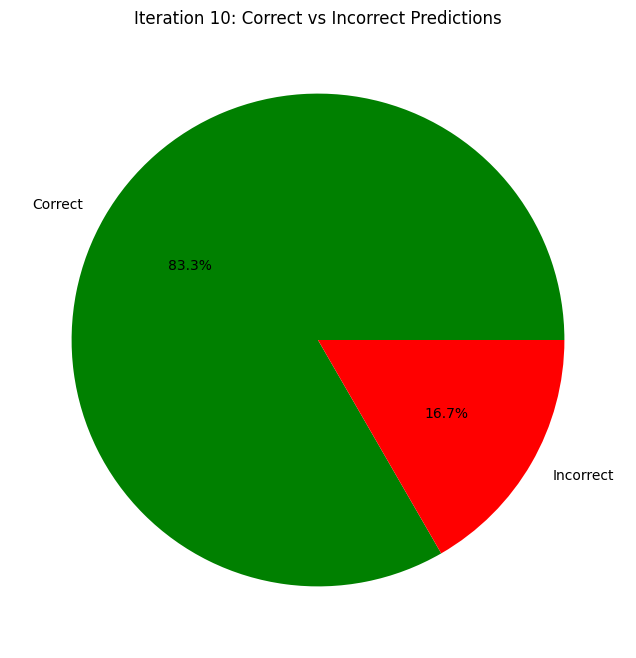

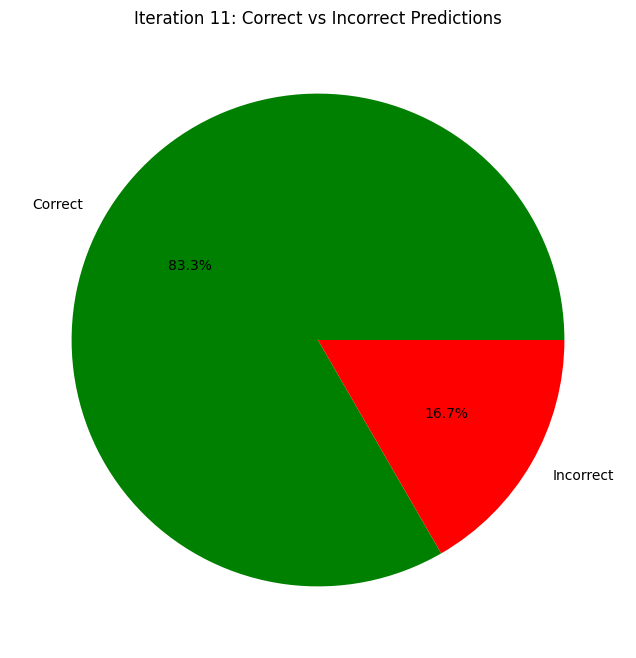

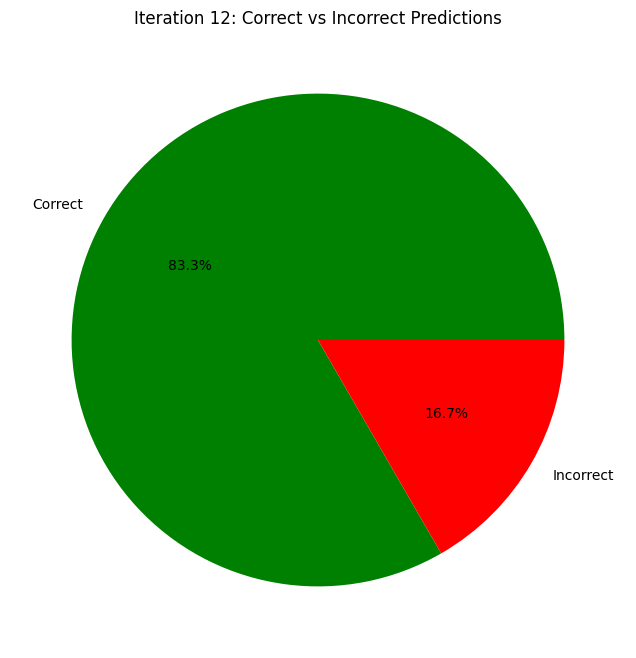

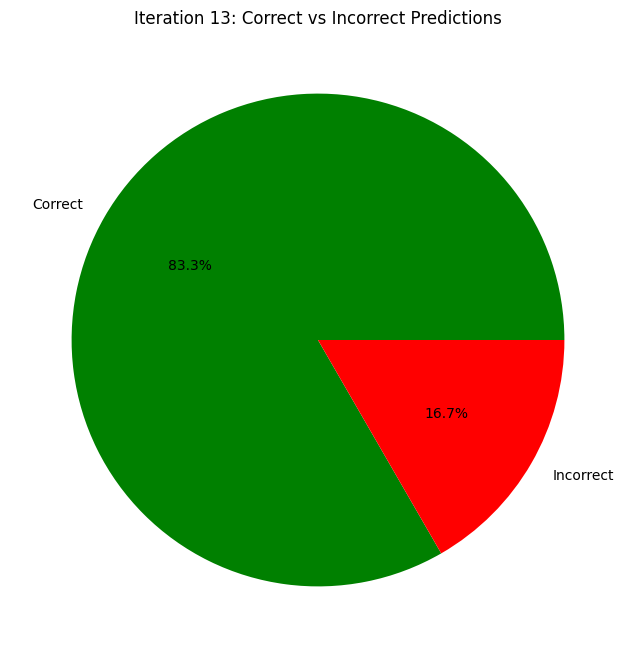

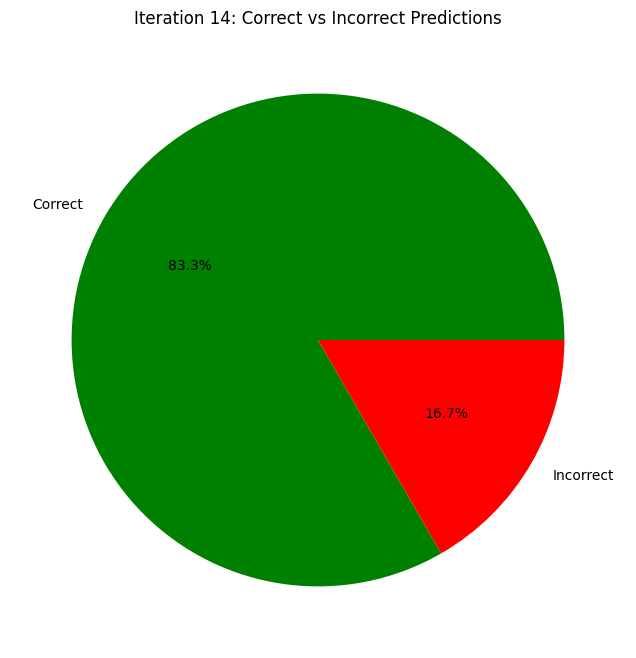

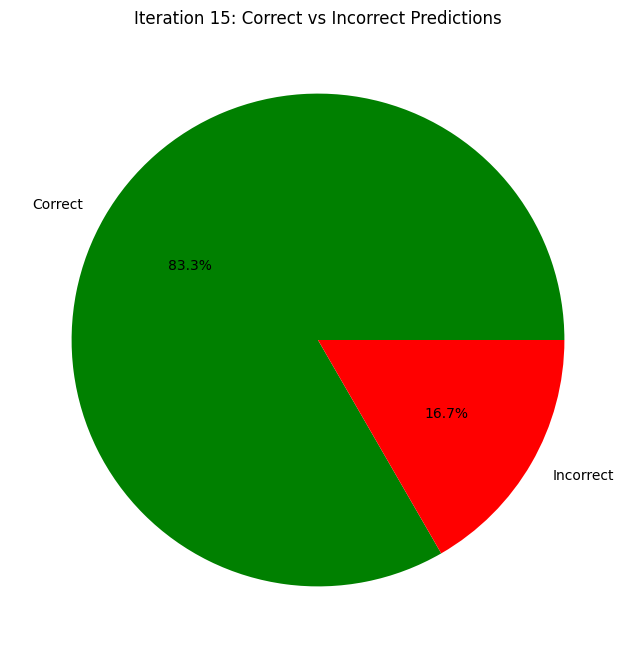

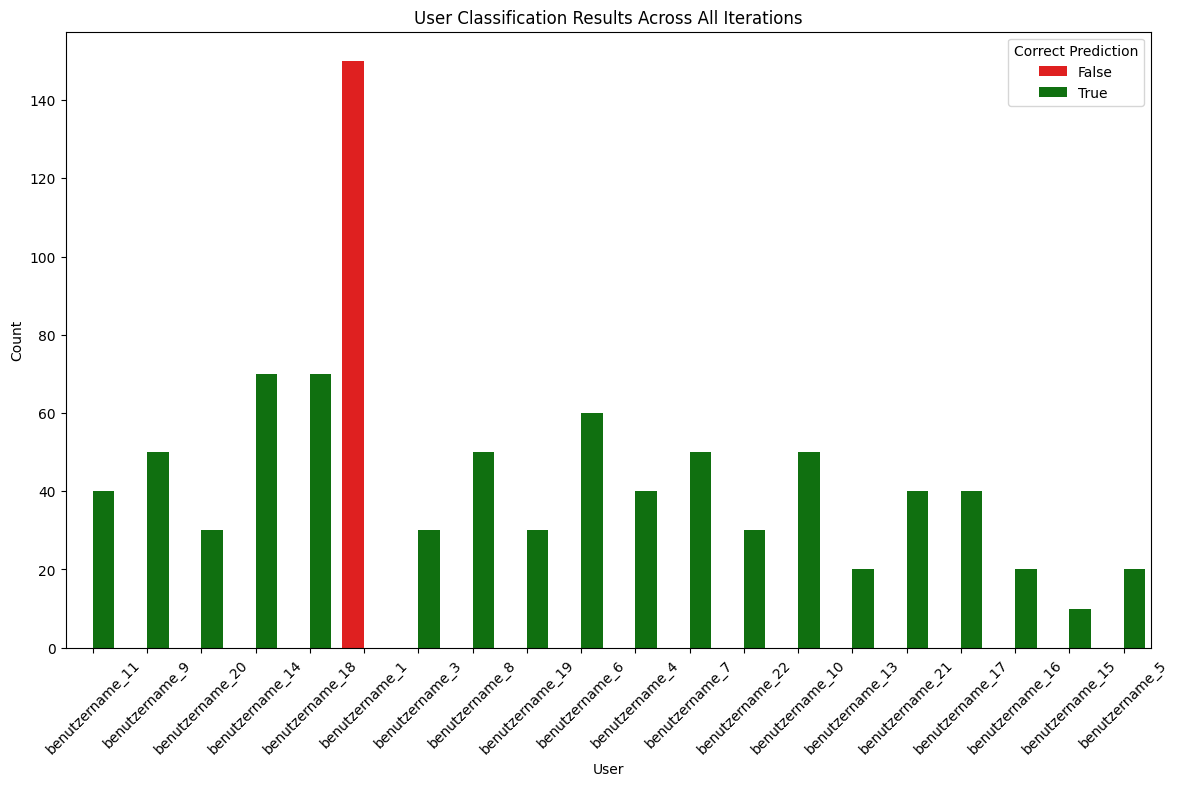

In [ ]:
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import pandas as pd

# Funktion zur Auswahl zufälliger Samples von verschiedenen Benutzern
def get_random_samples(user_dfs, example_user_id, num_users=5, num_samples_per_user=10):
    selected_users = random.sample([user_id for user_id in user_dfs.keys() if user_id != example_user_id], num_users)
    samples = []
    labels = []
    user_labels = []
    
    for user_id in selected_users:
        user_samples = user_dfs[user_id].sample(n=num_samples_per_user, random_state=42)
        for _, row in user_samples.iterrows():
            image = process_image_rgb(row['sampleData'])
            if image is not None:
                samples.append(image)
                labels.append(0)  # Negative Beispiel
                user_labels.append(user_id)
    
    # Füge positive Beispiele hinzu
    user_samples = user_dfs[example_user_id].sample(n=num_samples_per_user, random_state=42)
    for _, row in user_samples.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            samples.append(image)
            labels.append(1)  # Positive Beispiel
            user_labels.append(example_user_id)
    
    return np.array(samples), np.array(labels), user_labels

# Funktion zur Durchführung der Analyse
def analyze_model(model, user_dfs, example_user_id, iterations=15, num_users=5, num_samples_per_user=10):
    all_results = []
    
    for i in range(iterations):
        X_samples, y_samples, user_labels = get_random_samples(user_dfs, example_user_id, num_users, num_samples_per_user)
        y_pred = model.predict(X_samples)
        y_pred_classes = (y_pred > 0.5).astype("int32").flatten()
        
        # Textuelle Analyse
        print(f"Iteration {i+1}")
        print(classification_report(y_samples, y_pred_classes))
        
        all_results.append((y_samples, y_pred_classes, user_labels))
    
    return all_results

# Funktion zur grafischen Darstellung der Benutzerklassifikationen für alle Iterationen
def plot_user_classifications_all_iterations(results, example_user_id):
    combined_df = pd.DataFrame()
    
    for i, (y_samples, y_pred_classes, user_labels) in enumerate(results):
        df = pd.DataFrame({'User': user_labels, 'True Label': y_samples, 'Predicted Label': y_pred_classes})
        df['Correct'] = df['True Label'] == df['Predicted Label']
        df['Iteration'] = i + 1
        combined_df = pd.concat([combined_df, df], ignore_index=True)
    
    # Kreisdiagramme für jede Iteration
    for i in range(1, 16):
        iteration_df = combined_df[combined_df['Iteration'] == i]
        correct_count = iteration_df['Correct'].sum()
        incorrect_count = len(iteration_df) - correct_count
        
        plt.figure(figsize=(8, 8))
        plt.pie([correct_count, incorrect_count], labels=['Correct', 'Incorrect'], autopct='%1.1f%%', colors=['green', 'red'])
        plt.title(f'Iteration {i}: Correct vs Incorrect Predictions')
        plt.show()
    
    # Zusammenfassende grafische Darstellung
    plt.figure(figsize=(14, 8))
    sns.countplot(data=combined_df, x='User', hue='Correct', palette={True: 'green', False: 'red'}, dodge=True)
    plt.title('User Classification Results Across All Iterations')
    plt.xlabel('User')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Correct Prediction')
    plt.show()

# Beispiel für Benutzer 1
example_user_id = 'benutzername_1'

# Analyse durchführen
results = analyze_model(model, user_dfs, example_user_id, iterations=15)

# Grafische Darstellung der Benutzerklassifikationen für alle Iterationen
plot_user_classifications_all_iterations(results, example_user_id)